# Simple examples to create and access a database with sqlite3

In [1]:
# Import necessary libraries
import sqlite3, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define some helper variables
data_dir_path = "../data_raw/databases/"

# Helper functions

In [2]:
# Define some helper functions

def display_info(data):    
    for k, v in data.items():
        if isinstance(v, list):
            print(f"{k}:")
            for element in v:
                for sub_k, sub_v in element.items():
                    if isinstance(sub_v, list):
                        print(f"  -----  {sub_k}:")
                        for item in sub_v:
                            print(f"             {item}")
                    else:
                        print(f"  -----  {sub_k}: {sub_v}")
                print("  -------------------- \n ")
        else:
            print(f"{k}: {v}")

# Create and access simple database

In [2]:
# Define a name for the database include the path to the correct folder
db_name = "tutorial.db"
path = data_dir_path + db_name
print(f"Creating connection to database at: {path}")

# Create a connection with the database and implicitly create it if it does not exist
conn = sqlite3.connect(path)
print("Connection created successfully.")

Creating connection to database at: ../data_raw/databases/tutorial.db
Connection created successfully.


In [3]:
# Create a cursor to execute SQL commands
cur = conn.cursor()

# Right now the database is empty, we can check this by executing a simple query 
# that lists all the tables in the database
res = cur.execute("SELECT name FROM sqlite_master").fetchall()
print(f"Tables in the database: {res}")

Tables in the database: []


In [4]:
# Execute a simple query that creates a table named 
# 'students' with three columns: 'name', 'age' and 'score'.
cur.execute("CREATE TABLE IF NOT EXISTS students (name, age, score)")

# Check again the tables in the database to see that the table has been created
res = cur.execute("SELECT name FROM sqlite_master").fetchall()
print(f"Tables in the database: {res}")

Tables in the database: [('students',)]


In [5]:
# Insert data on the database in different ways


# 1) Insert a single record literally
cur.execute("INSERT INTO students VALUES ('Alice', 20, 85)")


# 2) Insert many records literally
cur.execute("INSERT INTO students VALUES ('Bob', 22, 90), ('Charlie', 19, 78)")


# 3) Insert a single record using parameters
cur.execute("INSERT INTO students VALUES (?, ?, ?)", ('David', 21, 88)) 
# This is a good practice to avoid SQL injection attacks. 
# ? are placeholders for the values that will be inserted.


# 4) Insert many records using parameters
students_data = [('Eve', 20, 92), ('Frank', 23, 80)]
cur.executemany("INSERT INTO students VALUES (?, ?, ?)", students_data)


# !!) Incorrect insertion with a mistake in the query
try:
    cur.execute("INSERT INTO students VALUES ('Grace', 22)")
except sqlite3.OperationalError as e:
    print(f"Error inserting data: {e}")


# The INSERT statement implicitly opens a transaction, 
# which needs to be committed before changes are saved in the database
conn.commit()


Error inserting data: table students has 3 columns but 2 values were supplied


In [ ]:
# Simple inspections


# Get the number of records in the table
res = cur.execute("SELECT COUNT(*) FROM students").fetchone()
print(f"Number of records in the students table: {res[0]}")
# Uses the function COUNT(*) to count the number of records in the students table.
# which returns a single value, so we use fetchone() to get it and then access the first element of the tuple with [0].

# Get the column names of the table
res = cur.execute("PRAGMA table_info(students)").fetchall()
# The PRAGMA command is a special command to query or change database settings and metadata. 
# In this case, we use it to get information about the structure of the students table, including the column names.
# The result is a list of tuples, where each tuple contains information about a column in the table.
# We extract the column names by taking the second element of each tuple (index 1) and create a list of column names.

column_names = [col[1] for col in res]
print(f"Column names in the students table: {column_names}")



Number of records in the students table: 6
Column names in the students table: ['name', 'age', 'score']


In [9]:
# Query the data from the database

# 1) Query all records
res = cur.execute("SELECT * FROM students").fetchall()
# The fetchall() method retrieves all the results of the query as a list of tuples.
# The * symbol means "all columns".
print("1) All students:", res, "\n")

# 2) Query specific columns
res = cur.execute("SELECT name, score FROM students").fetchall()
print("2) Students' names and scores:", res, "\n")

# 3) Query with a condition
res = cur.execute("SELECT * FROM students WHERE age > 20").fetchall()
print("3) Students older than 20:", res, "\n")

# 4) Query with multiple conditions
res = cur.execute("SELECT * FROM students WHERE age > 21 AND score > 85").fetchall()
print("4) Students older than 21 with score greater than 85:", res, "\n")

# 5) Query with an OR condition
res = cur.execute("SELECT * FROM students WHERE age < 20 OR score > 90").fetchall()
print("5) Students younger than 20 or with score greater than 90:", res, "\n")

# 6) Query with a LIKE condition
res = cur.execute("SELECT name FROM students WHERE name LIKE 'A%'").fetchall()
# The LIKE operator is used to search for a specified pattern in a column.
# 'A%' means that the name should start with 'A' followed by any characters.
print("6) Students whose name starts with 'A':", res, "\n")

# 7) On top of every query you can add a limit to the number of results returned
res = cur.execute("SELECT * FROM students WHERE age > 20 LIMIT 2").fetchall()
print("7) Students older than 20 and limit to 2 results:", res, "\n")

# 8) You can also order the results by a specific column
res = cur.execute("SELECT * FROM students ORDER BY score DESC").fetchall()
print("8) Students ordered by score (descending):", res, "\n")

# 9) Rigth way to write the query to avoid SQL injection attacks
res = cur.execute("SELECT * FROM students WHERE age > ? AND score > ?", (21, 85)).fetchall()
print("9) Students older than 21 with score greater than 85 (using parameters):", res, "\n")



1) All students: [('Alice', 20, 85), ('Bob', 22, 90), ('Charlie', 19, 78), ('David', 21, 88), ('Eve', 20, 92), ('Frank', 23, 80)] 

2) Students' names and scores: [('Alice', 85), ('Bob', 90), ('Charlie', 78), ('David', 88), ('Eve', 92), ('Frank', 80)] 

3) Students older than 20: [('Bob', 22, 90), ('David', 21, 88), ('Frank', 23, 80)] 

4) Students older than 21 with score greater than 85: [('Bob', 22, 90)] 

5) Students younger than 20 or with score greater than 90: [('Charlie', 19, 78), ('Eve', 20, 92)] 

6) Students whose name starts with 'A': [('Alice',)] 

7) Students older than 20 and limit to 2 results: [('Bob', 22, 90), ('David', 21, 88)] 

8) Students ordered by score (descending): [('Eve', 20, 92), ('Bob', 22, 90), ('David', 21, 88), ('Alice', 20, 85), ('Frank', 23, 80), ('Charlie', 19, 78)] 

9) Students older than 21 with score greater than 85 (using parameters): [('Bob', 22, 90)] 



In [10]:
# Update records in the database

res = cur.execute("SELECT * FROM students").fetchall()
print("Data before update:", res, "\n")


# 1) Update a single record
cur.execute("UPDATE students SET score = 95 WHERE name = 'Alice'")
res = cur.execute("SELECT * FROM students").fetchall()
print("Data first update:", res, "\n")

# 2) Update multiple records
cur.execute("UPDATE students SET score = score + 5 WHERE age < 21")
res = cur.execute("SELECT * FROM students").fetchall()
print("Data secnd update:", res, "\n")

# 3) Update using parameters
cur.execute("UPDATE students SET score = ? WHERE name = ?", (85, 'Bob'))    
res = cur.execute("SELECT * FROM students").fetchall()
print("Data third update:", res, "\n")


Data before update: [('Alice', 20, 85), ('Bob', 22, 90), ('Charlie', 19, 78), ('David', 21, 88), ('Eve', 20, 92), ('Frank', 23, 80)] 

Data first update: [('Alice', 20, 95), ('Bob', 22, 90), ('Charlie', 19, 78), ('David', 21, 88), ('Eve', 20, 92), ('Frank', 23, 80)] 

Data secnd update: [('Alice', 20, 100), ('Bob', 22, 90), ('Charlie', 19, 83), ('David', 21, 88), ('Eve', 20, 97), ('Frank', 23, 80)] 

Data third update: [('Alice', 20, 100), ('Bob', 22, 85), ('Charlie', 19, 83), ('David', 21, 88), ('Eve', 20, 97), ('Frank', 23, 80)] 



In [11]:
# Delete records from the database
res = cur.execute("SELECT * FROM students").fetchall()
print("Data before deletion:", res, "\n")

# 1) Delete a single record
cur.execute("DELETE FROM students WHERE name = 'Charlie'")
res = cur.execute("SELECT * FROM students").fetchall()
print("Data after deleting Charlie:", res, "\n")

# 2) Delete multiple records
cur.execute("DELETE FROM students WHERE age > 22")
res = cur.execute("SELECT * FROM students").fetchall()
print("Data after deleting students older than 22:", res, "\n")

# 3) Delete using parameters
cur.execute("DELETE FROM students WHERE name = ?", ('David',)) 
res = cur.execute("SELECT * FROM students").fetchall()
print("Data after deleting David:", res, "\n")

# 4) Delete the table (do not run for now)
cur.execute("DROP TABLE IF EXISTS students")
try:
    res = cur.execute("SELECT * FROM students").fetchall()
except sqlite3.OperationalError as e:
    print(f"Error querying data: {e}")

# Commit the changes to the database otherwise they will not be saved after the connection is closed
conn.commit()
conn.close()

Data before deletion: [('Alice', 20, 100), ('Bob', 22, 85), ('Charlie', 19, 83), ('David', 21, 88), ('Eve', 20, 97), ('Frank', 23, 80)] 

Data after deleting Charlie: [('Alice', 20, 100), ('Bob', 22, 85), ('David', 21, 88), ('Eve', 20, 97), ('Frank', 23, 80)] 

Data after deleting students older than 22: [('Alice', 20, 100), ('Bob', 22, 85), ('David', 21, 88), ('Eve', 20, 97)] 

Data after deleting David: [('Alice', 20, 100), ('Bob', 22, 85), ('Eve', 20, 97)] 

Error querying data: no such table: students


In [12]:
# Include again the table and the data to have it available for the next tutorial
conn = sqlite3.connect(path)
cur = conn.cursor()
cur.execute("CREATE TABLE IF NOT EXISTS students (name, age, score)")

students_data = [('Alice', 20, 85), ('Bob', 22, 90), ('Charlie', 19, 78), ('David', 21, 88), ('Eve', 20, 92), ('Frank', 23, 80)] 
cur.executemany("INSERT INTO students VALUES (?, ?, ?)", students_data)
conn.commit()

# Print all data
res = cur.execute("SELECT * FROM students").fetchall()
print("Final data in the students table:", res, "\n")

Final data in the students table: [('Alice', 20, 85), ('Bob', 22, 90), ('Charlie', 19, 78), ('David', 21, 88), ('Eve', 20, 92), ('Frank', 23, 80)] 



In [13]:
# Now we can do the same with pandas, which provides a more convenient interface 
# to work with databases and allows us to easily convert the results of 
# queries into DataFrames for further analysis.

# There are several ways to read data from a database into a pandas DataFrame.

# 1) Getting a result set from a query and converting it to a DataFrame
conn = sqlite3.connect(path)
query = "SELECT * FROM students"
res = conn.execute(query).fetchall()
conn.close()
print("Result set from query:", res, "\n" )
df = pd.DataFrame(res, columns=['name', 'age', 'score'])
print("DataFrame created from result set:")

df

Result set from query: [('Alice', 20, 85), ('Bob', 22, 90), ('Charlie', 19, 78), ('David', 21, 88), ('Eve', 20, 92), ('Frank', 23, 80)] 

DataFrame created from result set:


,name,age,score
0,Alice,20,85
1,Bob,22,90
2,Charlie,19,78
3,David,21,88
4,Eve,20,92
5,Frank,23,80


In [14]:
# A more convenient way to read data from a database into a DataFrame 
# is to use the read_sql_query function from pandas, which allows us to 
# directly execute a SQL query and get the results as a DataFrame.

conn = sqlite3.connect(path)
query = "SELECT * FROM students"
df = pd.read_sql_query(query, conn)
conn.close()
# The pandas function read_sql_query takes a SQL query and a database connection as input, 
# executes the query and returns the results as a DataFrame.

df

,name,age,score
0,Alice,20,85
1,Bob,22,90
2,Charlie,19,78
3,David,21,88
4,Eve,20,92
5,Frank,23,80


In [15]:
# Many of the operations we have seen before can be done directly on the DataFrame,
# which provides a more convenient interface for data manipulation and analysis. 
# The advantage of sql is that it is more efficient for large datasets and allows us 
# to perform complex queries directly on the database without having to load all the data into memory.

df_new = df[df['age'] > 20]
print("Students older than 20 (using pandas):")
df_new

Students older than 20 (using pandas):


,name,age,score
1,Bob,22,90
3,David,21,88
5,Frank,23,80


# Real DataBases

## SUBSIDIES

In [4]:
# We can inspect any of the 3 databases available
# "subsidies.db", "parcels_filtered.db", "parcels_summary.db"

# Let's inspect the "subsidies.db" database first.

db_name = "subsidies.db"
path = data_dir_path + db_name
print(f"Creating connection to database at: {path}")
conn = sqlite3.connect(path)
cur = conn.cursor()

Creating connection to database at: ../data_raw/databases/subsidies.db


In [5]:
# Inspect the tables in the database
res = cur.execute("SELECT name FROM sqlite_master").fetchall()
print(f"Tables in the database: {res}")


# 'subsidies' is the main table of the database
# 'sqlite_sequence' is a special table that keeps track of the last rowid for each table in the database,
# 'idx_year_country' is an index on the 'subsidies' table to speed up queries that filter by 'year' and 'country'.

Tables in the database: [('subsidies',), ('sqlite_sequence',), ('idx_year_country',)]


In [6]:
# Get the column names of the table
res = cur.execute("PRAGMA table_info(subsidies)").fetchall()
column_names = [col[1] for col in res]
print(f"Column names in the students table: {column_names}")

# Get the number of records in the table
res = cur.execute("SELECT COUNT(*) FROM subsidies").fetchone()
print(f"Number of records in the table: {res[0]} \n")

Column names in the students table: ['id', 'country', 'year', 'amount', 'currency', 'recipient_name', 'currency_original', 'pk', 'recipient_address', 'recipient_id', 'recipient_country', 'amount_original', 'recipient_fingerprint', 'scheme', 'scheme_id', 'extra_data']
Number of records in the table: 151327357 



In [7]:
# Make some queries to get a feel of the data
query = "SELECT recipient_name , amount FROM subsidies WHERE year = 2020 AND country = 'IT' LIMIT 5"
df = pd.read_sql_query(query, conn)
print("Some subsidies in Italy in 2020:")
df

Some subsidies in Italy in 2020:


,recipient_name,amount
0,CONSIGLIO PER LA RICERCA IN AGRIC. E L'ANALISI...,4805264.44
1,SOCIETA' PER LA BONIFICA DEI TERRENI FERRARESI...,3124753.36
2,APOFRUIT ITALIA - SOC. COOP. AGRICOLA,3050922.59
3,AOP GRUPPO VI.VA. VISIONE VALORE SOCIETA' COOP...,34174546.38
4,F.IN.A.F. FIRST INTERNETIONAL ASSOCIATION FRUI...,31259109.81


In [8]:
# More complicated queries can be done directly on the database, 
# which is more efficient than loading all the data into a DataFrame and then filtering it.

year = 2023
country = 'IT'
query = f"""
            SELECT 
                    recipient_name,
                    SUM(amount) AS total_amount
            FROM 
                    subsidies
            WHERE 
                    year = {year} AND country = '{country}'
            GROUP BY 
                    recipient_name
            ORDER BY 
                    total_amount DESC
            """
# This query selects the recipient_name and the total amount of subsidies received by each recipient in Italy in 2023,
# groups the results by recipient_name, orders them by total_amount in descending order and limits the results to the top 10 recipients.
df = pd.read_sql_query(query, conn)
print(f"Sorted recipients of subsidies in {country} in {year}:")
df

Sorted recipients of subsidies in IT in 2023:


,recipient_name,total_amount
0,F.IN.A.F. FIRST INTERNETIONAL ASSOCIATION FRUI...,58642101.54
1,AOP GRUPPO VI.VA. VISIONE VALORE SOCIETA' COOP...,41001421.94
2,ASSOCIAZIONE ITALIANA ALLEVATORI - IN BREVE DE...,23321306.48
3,VOG - VERBAND DER SUEDTIROLER OBSTGEN. - GEN. ...,15447958.98
4,APOT S.C.A.,14407958.68
...,...,...
86274,ORNELLA TAMBURINI,16886.46
86275,CARMELA GIULIA PISEDDU,16886.33
86276,MARIACHIARA BALBI,16886.03
86277,ESTERINA DE SORICELLIS,16886.02


List of total amounts (5 initial elements): [58642101.54, 41001421.94, 23321306.48, 15447958.98, 14407958.68] ...
Simple statistics 

Number of recipients: 86279
Total amount of subsidies: 5359826679.43 euro
The average amount of subsidies per recipient: 62122.03061498163 euro


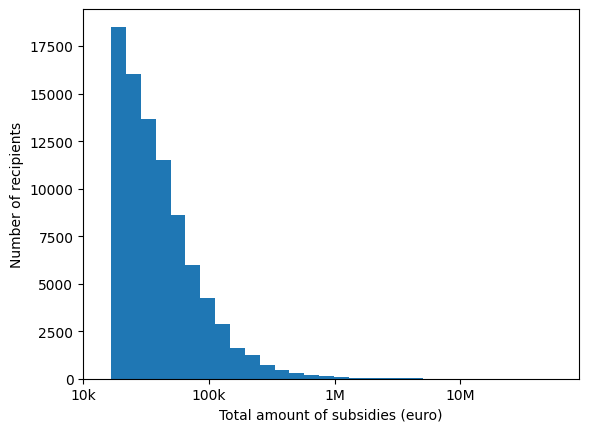

In [9]:
# Now we can do some analysis with the data if we want.

# Extract the amount as a list of values
amount = df['total_amount'].tolist()
print("List of total amounts (5 initial elements):", amount[:5], "...")


# Compute some statistics on the amount
num_recipients = len(amount)
total_amount = sum(amount)
average_amount = total_amount / num_recipients 
print(f"Simple statistics \n")
print(f"Number of recipients: {num_recipients}")
print(f"Total amount of subsidies: {total_amount} euro")
print(f"The average amount of subsidies per recipient: {average_amount} euro")

# Plot the distribution of the log-amount
plt.hist(np.log10(amount), bins=30)
plt.xticks([4,5,6,7], ['10k', '100k', '1M', '10M'])
plt.xlabel('Total amount of subsidies (euro)')
plt.ylabel('Number of recipients')
plt.show()

In [10]:
# Close the connection to the database
conn.close()

## PARCELS

In [11]:
db_name = "parcels_filtered.db"
path = data_dir_path + db_name
print(f"Creating connection to database at: {path}")
conn = sqlite3.connect(path)
cur = conn.cursor()

Creating connection to database at: ../data_raw/databases/parcels_filtered.db


In [12]:
# Go to the second database and inspect the tables
res = cur.execute("SELECT name FROM sqlite_master").fetchall()
print(f"Tables in the database: {res}")


Tables in the database: [('parcels',), ('idx_id',)]


In [15]:
# Get the column names of the table
res = cur.execute("PRAGMA table_info(parcels)").fetchall()
column_names = [col[1] for col in res]
print(f"Column names in the students table: {column_names}")

# Get the number of records in the table
res = cur.execute("SELECT COUNT(*) FROM parcels").fetchone()
print(f"Number of records in the table: {res[0]} \n")

Column names in the students table: ['id', 'data']
Number of records in the table: 9825009 



In [16]:
# Extract the first record to get a feel of the data
query = "SELECT * FROM parcels LIMIT 1"
res = cur.execute(query).fetchone()
print("Some parcel in the database:")
print(res)

Some parcel in the database:
('12806183', '{"parcelId":12806183,"parcelNumber":"*66","cadMunicipalityId":1360,"cadMunicipalityRegNum":"300543","cadMunicipalityName":"KULA ATLAGIĆ","institutionId":117,"address":"RUŠEVINE","area":"439","buildingRemark":1,"detailSheetNumber":"8","hasBuildingRight":false,"parcelParts":[{"parcelPartId":34913945,"name":"PAŠNJAK","area":"300","possessionSheetId":7315148,"possessionSheetNumber":"666","lastChangeLogNumber":"10/2018","building":false},{"parcelPartId":34913946,"name":"VOĆNJAK","area":"139","possessionSheetId":7315148,"possessionSheetNumber":"666","lastChangeLogNumber":"10/2018","building":false}],"possessionSheets":[{"possessionSheetId":7315148,"possessionSheetNumber":"666","cadMunicipalityId":1360,"cadMunicipalityRegNum":"300543","cadMunicipalityName":"KULA ATLAGIĆ","possessionSheetTypeId":1,"possessors":[{"name":"Špiro Končarević","ownership":"1/2","address":"Beograd, SRBIJA"},{"name":"Nikola Končarević","ownership":"1/2","address":"Beograd, SR

In [17]:
# Improve Visualization of the data
data = json.loads(res[1])
display_info(data)

parcelId: 12806183
parcelNumber: *66
cadMunicipalityId: 1360
cadMunicipalityRegNum: 300543
cadMunicipalityName: KULA ATLAGIĆ
institutionId: 117
address: RUŠEVINE
area: 439
buildingRemark: 1
detailSheetNumber: 8
hasBuildingRight: False
parcelParts:
  -----  parcelPartId: 34913945
  -----  name: PAŠNJAK
  -----  area: 300
  -----  possessionSheetId: 7315148
  -----  possessionSheetNumber: 666
  -----  lastChangeLogNumber: 10/2018
  -----  building: False
  -------------------- 
 
  -----  parcelPartId: 34913946
  -----  name: VOĆNJAK
  -----  area: 139
  -----  possessionSheetId: 7315148
  -----  possessionSheetNumber: 666
  -----  lastChangeLogNumber: 10/2018
  -----  building: False
  -------------------- 
 
possessionSheets:
  -----  possessionSheetId: 7315148
  -----  possessionSheetNumber: 666
  -----  cadMunicipalityId: 1360
  -----  cadMunicipalityRegNum: 300543
  -----  cadMunicipalityName: KULA ATLAGIĆ
  -----  possessionSheetTypeId: 1
  -----  possessors:
             {'name': 

In [77]:
# Close the connection to the database
conn.close()

## PARCELS FLAT

In [2]:
db_name = "parcels_summary.db"
path = data_dir_path + db_name
print(f"Creating connection to database at: {path}")
conn = sqlite3.connect(path)
cur = conn.cursor()

# Add an index for possesorname to speed up queries that filter by this column
# This migth take some minutes
cur.execute("CREATE INDEX IF NOT EXISTS idx_possesorname ON summary_data(possesorname)")
conn.commit()

Creating connection to database at: ../data_raw/databases/parcels_summary.db


In [3]:
# Go to the second database and inspect the tables
res = cur.execute("SELECT name FROM sqlite_master").fetchall()
print(f"Tables in the database: {res}")


Tables in the database: [('summary_data',), ('idx_parcelId',), ('idx_parcelarea',), ('idx_nameusage',), ('idx_partarea',), ('idx_nparcelparts',), ('idx_possesorname',)]


In [6]:
# Check if the idx_possesorname index has been created
# otherwise the next queries that filter by possesorname will be very slow

if ('idx_possesorname',) in res:
    print("The idx_possesorname index has been created successfully.")
else:
    print("The idx_possesorname index has not been created.")
    raise Exception("The idx_possesorname index has not been created.")

The idx_possesorname index has been created successfully.


In [7]:
# Get the column names of the table
res = cur.execute("PRAGMA table_info(summary_data)").fetchall()
column_names = [col[1] for col in res]
print(f"Column names in the students table: {column_names}")

# Get the number of records in the table
res = cur.execute("SELECT COUNT(*) FROM summary_data").fetchone()
print(f"Number of records in the table: {res[0]} \n")

Column names in the students table: ['parcelId', 'parcelarea', 'nparcelparts', 'cadMunicipalityName', 'address', 'possessionSheetId', 'nameusage', 'partarea', 'parcelPartId', 'possesorname', 'ownership', 'possesoraddress']
Number of records in the table: 74487442 



In [8]:
# Display fist records to get a feel of the data
query = "SELECT * FROM summary_data  LIMIT 1 "
df = pd.read_sql_query(query, conn)
print("Some summary data:")
df

Some summary data:


,parcelId,parcelarea,nparcelparts,cadMunicipalityName,address,possessionSheetId,nameusage,partarea,parcelPartId,possesorname,ownership,possesoraddress
0,12806183,439.0,2,KULA ATLAGIĆ,RUŠEVINE,7315148,PAŠNJAK,300.0,34913945,Špiro Končarević,1/2,"Beograd, SRBIJA"


In [9]:
# Get all the different types of 'nameusage' in the database with the count of records for each type in descending order
query = "SELECT nameusage, COUNT(*) as count FROM summary_data GROUP BY nameusage ORDER BY count DESC"
df = pd.read_sql_query(query, conn)
print("Different types of 'nameusage' in the database with the count of records for each type:")
df

Different types of 'nameusage' in the database with the count of records for each type:


,nameusage,count
0,PAŠNJAK,27918522
1,ORANICA,27098589
2,LIVADA,7280822
3,VOĆNJAK,5653082
4,VINOGRAD,4233134
...,...,...
3147,ŠKOLSKO NOGOMETNO IG,1
3148,ŠPORTSKI OBJEKAT,1
3149,ŠTAGALJ DVORIŠTE,1
3150,ŠTERNA,1


## NEW QUERIES

In [10]:
# Actual list of nameusages we care about
list_nameusages = ["VRT",
                "VOĆNJAK - RASADNIK",
                "VOĆNJAK",
                "VINOGRAD",
                "TRSTIK",
                "RIBNJAK",
                "PAŠNJAK",
                "ORANICA-PLASTENIK",
                "ORANICA - PLASTENIK",
                "ORANICA",
                "MOČVARA (BARA)",
                "MOČVARA",
                "MASLINIK - RASADNIK",
                "MASLINIK",
                "LIVADA"]

In [11]:
# Now we get the number of entries that have a specific possesorname
possesorname = 'REPUBLIKA HRVATSKA'

query = f"SELECT COUNT(*) FROM summary_data WHERE possesorname = '{possesorname}'"
res = cur.execute(query).fetchone()
print(f"Number of entries with possesorname '{possesorname}': {res[0]}")

Number of entries with possesorname 'REPUBLIKA HRVATSKA': 1614326


In [12]:
total = 74487442 # Total number of entries in the database, obtained with the query "SELECT COUNT(*) FROM summary_data" 
contry = 1614326 # Number of entries with possesorname 'REPUBLIKA HRVATSKA', obtained with the query "SELECT COUNT(*) FROM summary_data WHERE possesorname = 'REPUBLIKA HRVATSKA'"


percentage = (contry / total) * 100
print(f"Percentage of entries with possesorname '{possesorname}': {percentage :.3f}%")

Percentage of entries with possesorname 'REPUBLIKA HRVATSKA': 2.167%


In [14]:
# compute total sum of partarea in the database
query = "SELECT SUM(partarea) FROM summary_data"
res = cur.execute(query).fetchone()
print(f"Total sum of partarea in the database: {res[0]}")

# compute total sum of partarea for entries with a specific possesorname
possesorname = 'REPUBLIKA HRVATSKA'
query = f"SELECT SUM(partarea) FROM summary_data WHERE possesorname = '{possesorname}'"
res = cur.execute(query).fetchone()
print(f"Total sum of partarea for entries with possesorname '{possesorname}': {res[0]}")

Total sum of partarea in the database: 191967004816.0
Total sum of partarea for entries with possesorname 'REPUBLIKA HRVATSKA': 17557188839.0


In [15]:
total = 191967004816.0  # Total sum of partarea in the database, obtained with the query "SELECT SUM(partarea) FROM summary_data"
country = 17557188839.0 # Total sum of partarea for entries with possesorname 'REPUBLIKA HRVATSKA', obtained with the query "SELECT SUM(partarea) FROM summary_data WHERE possesorname = 'REPUBLIKA HRVATSKA'"
percentage = (country / total) * 100
print(f"Percentage of total partarea for entries with possesorname '{possesorname}': {percentage :.3f}%")

Percentage of total partarea for entries with possesorname 'REPUBLIKA HRVATSKA': 9.146%


In [16]:
# Get the parcelarea and partarea of the entries that have a specific possesorname and that their nameusage is in the list of predefined nameusages

possesorname = 'REPUBLIKA HRVATSKA'

query = f"""
            SELECT
                    partarea,
                    nameusage    
            FROM
                    summary_data
            WHERE
                    possesorname = '{possesorname}' AND nameusage IN ({','.join(['?']*len(list_nameusages))})
            """


df = pd.read_sql_query(query, conn, params=list_nameusages)
print(f"Parcelarea and partarea of entries with possesorname '{possesorname}' and nameusage in the list of predefined nameusages:")
df

Parcelarea and partarea of entries with possesorname 'REPUBLIKA HRVATSKA' and nameusage in the list of predefined nameusages:


,partarea,nameusage
0,2620.0,PAŠNJAK
1,1612.0,PAŠNJAK
2,1779.0,PAŠNJAK
3,1220.0,PAŠNJAK
4,1152.0,PAŠNJAK
...,...,...
1580358,98.0,ORANICA
1580359,278.0,ORANICA
1580360,95.0,ORANICA
1580361,270.0,ORANICA


In [23]:
total_area = df['partarea'].sum()

# Dictionary comprehension to compute the total sum of partarea for each nameusage in the list of predefined nameusages
usage_area = {}
for nameusage in list_nameusages:
    nameusage_area = df[df['nameusage'] == nameusage]['partarea'].sum()
    usage_area[nameusage] = nameusage_area

# Sort the dictionary by value in descending order
usage_area = dict(sorted(usage_area.items(), key=lambda item: item[1], reverse=True))

# Print percentage of total partarea for each nameusage

print(f"Percentage of total partarea for each nameusage with possesorname '{possesorname}': \n")
for nameusage, area in usage_area.items():
    print(f" '{nameusage}': {area} =  {area/total_area*100:.2f}% ")

Percentage of total partarea for each nameusage with possesorname 'REPUBLIKA HRVATSKA': 

 'ORANICA': 9652073641.0 =  58.33% 
 'PAŠNJAK': 5358039018.0 =  32.38% 
 'LIVADA': 1043456620.0 =  6.31% 
 'RIBNJAK': 163684458.0 =  0.99% 
 'VINOGRAD': 116117465.0 =  0.70% 
 'VOĆNJAK': 94593381.0 =  0.57% 
 'TRSTIK': 87248739.0 =  0.53% 
 'MASLINIK': 20605256.0 =  0.12% 
 'MOČVARA': 11450032.0 =  0.07% 
 'VRT': 294071.0 =  0.00% 
 'MOČVARA (BARA)': 281604.0 =  0.00% 
 'ORANICA-PLASTENIK': 223700.0 =  0.00% 
 'VOĆNJAK - RASADNIK': 20811.0 =  0.00% 
 'ORANICA - PLASTENIK': 9510.0 =  0.00% 
 'MASLINIK - RASADNIK': 0.0 =  0.00% 
